#Ejercicio en clase

Guía para sobrevivir a las prácticas calificadas. Esta es tu guía para sobrevivir a las prácticas calificadas del curso. Te acompañaré paso a paso para que puedas entender qué se te está preguntando, cómo abordar cada ejercicio y qué necesitas hacer para resolver esta y las siguientes evaluaciones del curso.


# **Paso 00** : Leamos y entandomos el caso

Es tu primer día en la **Oficina de Ciberdelitos Internacionales**. Apenas llegas, encuentras sobre tu escritorio el último archivo que dejó tu antecesor antes de renunciar: **`tu_data`**.

Nadie sabe exactamente qué pasó con los casos que estaba investigando, pero el archivo contiene información de cientos de víctimas de ciberdelitos:edad, sexo, nivel educativo, tipo de delito, monto perdido, denuncia, satisfacción con la atención recibida y lugar del atacante.

A partir de este momento, deberás utilizar las herramientas aprendidas en el curso para explorar, describir y analizar la información contenida en **`tu_data.csv`**.

Como parte de la organización inicial del trabajo, cargue la base de datos y

1. **Asigna un nombre de trabajo claro y consistente** que facilite su identificación durante el análisis.

2. **Para sustentar el análisis exploratorio**, presenta las variables disponibles que incluya su tipo de variable y sus medidas de tendencia central. A partir de eso, identifica qué medida o medidas de tendencia central resultan pertinentes para cada variable según su naturaleza y justifica su elección.

3. **Para caracterizar el perfil de las víctimas**, presenta la distribución de la variable monto perdido en una tabla de frecuencias que incluya las frecuencias absolutas, los porcentajes simples y los porcentajes acumulados, así como una representación gráfica que respete el orden de las categorías de la variable.

4. **Para identificar posibles diferencias en el monto perdido según el tipo de ciberdelito**, examina cómo varía el monto perdido (en USD) según los distintos tipos de ciberdelito. Presenta esta información mediante un diagrama de cajas (box plot) y, a partir de los resultados obtenidos, formule un hallazgo relevante para el análisis del caso.


# **Paso 01** : Descaga tu data

Lo primero que debes hacer es descarga ["tu data"](https://paideiacursos.pucp.edu.pe/mod/resource/view.php?id=3384495) que está subida en paideia y **guardala en tu carpeta de descargas** esto permitirá que funcione el codigo que hemos preparado para clase.

Del texto de la preguntas descubrimos que la base de datos tiene:

> "información de cientos de víctimas de ciberdelitos:edad, sexo, nivel educativo, tipo de delito, monto perdido, denuncia, satisfacción con la atención recibida y lugar del atacante".

Por lo tanto, la unidad de medida de la base es de "vicitmas de ciberdelitos", y las variables serán las caracteristicas de estas victimas. Este es un entendimientos fundamental, porque nos permite imaginar los datos.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Paso 02** : Carga tu data

Lo primero que tienes que hacer es cargar el archivo que descargaste anteriormente. Ejecucate el siguiente código y carga el archivo.

In [41]:
from google.colab import files # significa “trae la herramienta files de Google Colab para poder trabajar con archivos”.
# Esto abrirá un cuadro de diálogo para que selecciones tu archivo local

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Archivo "{filename}" subido exitosamente.')


Saving tu_data.csv to tu_data (3).csv
Archivo "tu_data (3).csv" subido exitosamente.


In [42]:
df = pd.read_csv('tu_data (2).csv') #Convierte el archivo en pase datos

## Nombre la base de datos

Necesitamos saber cómo se llama nuestro conjunto de datos y cómo se van modificando sus nombres cuando realizamos transformaciones. Esto nos permite llevar un registro claro de cada etapa del análisis y evitar confusiones sobre qué versión de los datos estamos utilizando en cada momento.

In [43]:
tu_data = df  #Cambiar el nombre de la base

# **Paso 03** : revisa tus datos
Ahora es importante que conozcas la estructura de tus datos. Antes de ejecutar cualquier código, revisa la base y plantea algunas preguntas que te ayuden a identificar cómo está organizada. La idea es que primero pienses qué información necesitas obtener y luego utilices pandas para encontrar las respuestas.

### ¿Qué dimensiones tiene tu_data?

In [44]:
tu_data2.shape

(400, 8)

## ¿Cómos se ven tus datos?

Con la función `head()` de pandas, visualizamos las primeras filas del conjunto:

```python
display(tu_data.head())
```

In [45]:
display(tu_data.head()) # Muestra las primeras filas para verificar

,tipo_ciberdelito,edad,sexo,nivel_educacion,monto_perdido_usd,denuncio,satisfaccion_atencion_escala_5,lugar_atacante
0,Malware,56,Femenino,Universitario,2594.0,No,0,América Latina
1,Phishing,69,Femenino,Técnico,2272.0,No,0,América Latina
2,Phishing,46,Femenino,Técnico,880.0,Sí,2,Europa
3,Phishing,32,Masculino,Secundaria,768.0,No,0,Desconocido
4,Robo de Identidad,60,Femenino,Técnico,557.0,No,0,Desconocido


## ¿Qué variables tiene mis datos?

La función `info()` de pandas nos muestra el nombre de cada variable, su tipo de dato y la cantidad de valores no faltantes:

```python
tu_data.info()
```

In [46]:
tu_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   tipo_ciberdelito                400 non-null    object 
 1   edad                            400 non-null    int64  
 2   sexo                            400 non-null    object 
 3   nivel_educacion                 400 non-null    object 
 4   monto_perdido_usd               400 non-null    float64
 5   denuncio                        400 non-null    object 
 6   satisfaccion_atencion_escala_5  400 non-null    int64  
 7   lugar_atacante                  400 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 25.1+ KB


# **Paso 04** : datos despritivos
En este paso calcularemos estadísticas descriptivas de nuestras variables. Utilizaremos la función `describe()` de `pandas`, que nos proporcionará medidas de tendencia central (media), dispersión (desviación estándar), y percentiles para variables numéricas, permitiéndonos entender la distribución y características principales de nuestros datos.

```python
tu_data.describe(include="all").round(2)
```

In [50]:
tu_data.describe(include="all").round(2) #incluye cuali y cuanti y 2 decimales

,tipo_ciberdelito,edad,sexo,nivel_educacion,monto_perdido_usd,denuncio,satisfaccion_atencion_escala_5,lugar_atacante
count,400,400.00,400,400,400.00,400,400.00,400
unique,4,NaN,2,4,NaN,2,NaN,6
top,Phishing,NaN,Femenino,Universitario,NaN,No,NaN,Desconocido
freq,130,NaN,215,129,NaN,249,NaN,103
mean,NaN,46.33,NaN,NaN,686.44,NaN,1.17,NaN
std,NaN,16.70,NaN,NaN,993.58,NaN,1.64,NaN
min,NaN,18.00,NaN,NaN,0.00,NaN,0.00,NaN
25%,NaN,32.00,NaN,NaN,89.50,NaN,0.00,NaN
50%,NaN,46.00,NaN,NaN,413.50,NaN,0.00,NaN
75%,NaN,61.00,NaN,NaN,875.25,NaN,3.00,NaN


# **Paso 05** : Recodifica una variable

In [57]:
Cortes = [0, 100, 500, 1000, tu_data['monto_perdido_usd'].max()]
Etiquetas = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
tu_data['Re_monto'] = pd.cut(tu_data['monto_perdido_usd'], bins=Cortes, labels=Etiquetas, right=False)



In [58]:
frecuencia_abs = tu_data['Re_monto'].value_counts().sort_index()
frecuencia_rel = tu_data['Re_monto'].value_counts(normalize=True).sort_index()
frecuencia_cum = frecuencia_rel.cumsum()

frecuencia_df = pd.DataFrame({
    'Frecuencia Absoluta': frecuencia_abs,
    'Porcentaje Simple': (frecuencia_rel * 100).round(2),
    'Porcentaje Acumulado': (frecuencia_cum * 100).round(2)
})

print("Tabla de Frecuencias para 'Re_monto':")
print(frecuencia_df)

Tabla de Frecuencias para 'Re_monto':
          Frecuencia Absoluta  Porcentaje Simple  Porcentaje Acumulado
Re_monto                                                              
Bajo                      102              25.56                 25.56
Medio                     126              31.58                 57.14
Alto                       91              22.81                 79.95
Muy Alto                   80              20.05                100.00


/tmp/ipykernel_1500/909898002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Re_monto', data=tu_data, palette='viridis', order=Etiquetas)


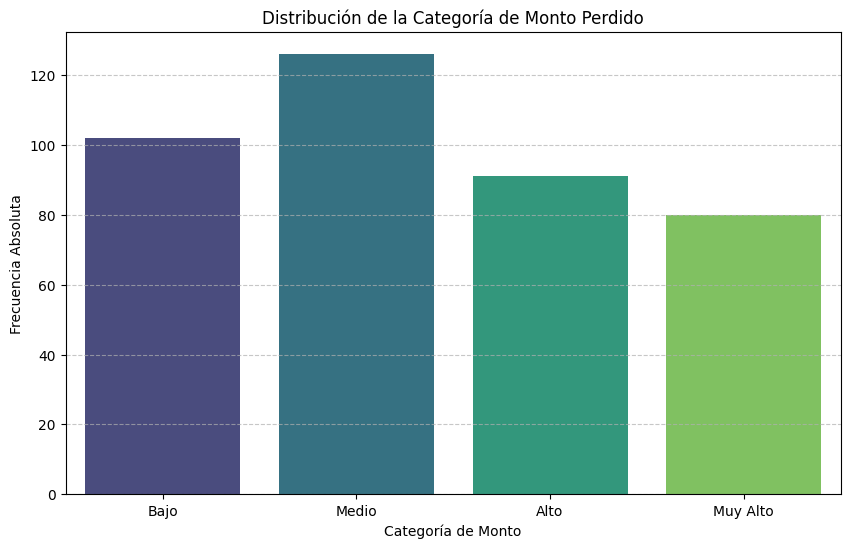

In [56]:
# 2. Representación gráfica (gráfico de barras)
plt.figure(figsize=(10, 6))
sns.countplot(x='Re_monto', data=tu_data, palette='viridis', order=Etiquetas)
plt.title('Distribución de la Categoría de Monto Perdido')
plt.xlabel('Categoría de Monto')
plt.ylabel('Frecuencia Absoluta')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Paso 06** : Construye un gráfico de cajas

/tmp/ipykernel_1500/1811174401.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo_ciberdelito', y='monto_perdido_usd', data=tu_data, palette='colorblind') #X es tu variable categoria #Y tu variable numerica


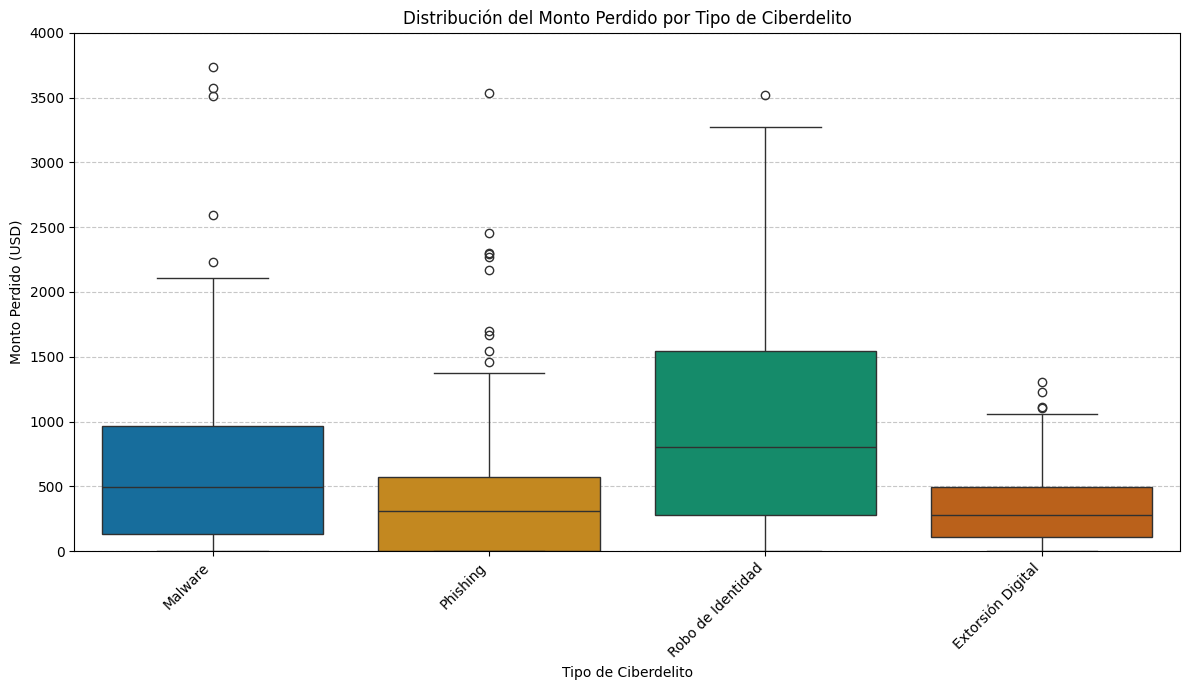

In [55]:
# Crear el gráfico de cajas para el monto_perdido por tipo_ciberdelito
plt.figure(figsize=(12, 7))
sns.boxplot(x='tipo_ciberdelito', y='monto_perdido_usd', data=tu_data, palette='colorblind') #X es tu variable categoria #Y tu variable numerica
plt.title('Distribución del Monto Perdido por Tipo de Ciberdelito')
plt.xlabel('Tipo de Ciberdelito')
plt.ylabel('Monto Perdido (USD)')
plt.ylim(0, 4000) # Set the y-axis limit
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()